In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)   # Should print: cuda

cpu


In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

2.12.1+cpu
False
None
0


In [3]:
import sys
print(sys.executable)

C:\Users\HP\miniconda3\python.exe


In [6]:
import sys
!{sys.executable} -m pip install pandas
import pandas as pd

train_labels = pd.read_csv("train/labels.csv")
train_labels.head()
#train_labels.tail()


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [7]:
print("Train images:", len(pd.read_csv("train/labels.csv")))
print("Test images:", len(pd.read_csv("test/labels.csv")))

Train images: 7200
Test images: 3600


In [8]:
print(train_labels['has_traffic_light'].value_counts())
print(train_labels['has_pedestrian'].value_counts())
print(train_labels['has_vehicle'].value_counts())

#print()
#print(train_labels[['has_traffic_light','has_pedestrian','has_vehicle']].value_counts())

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


In [9]:
import os #path fix

os.getcwd()
#cd /Users/maverick/Downloads/ML Safety Files


'C:\\Projects\\ML Safety Sose 26\\data'

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('train/rgb-front/000000.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
train_labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [12]:
sample_rows = train_labels.sample(5)
sample_rows.head()


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
5346,53460,True,False,True,438,0,109
773,7730,True,False,False,378,0,8
814,8140,True,True,True,231,362,4644
2159,21590,False,False,True,33,0,476
878,8780,True,True,True,423,41,1354


In [17]:
import sys

!{sys.executable} -m pip install \
    torch torchvision torchaudio \
    pandas numpy matplotlib pillow \
    scikit-learn tqdm opencv-python \
    jupyter ipykernel

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached fqdn-1.5.1-py3-none-any.whl

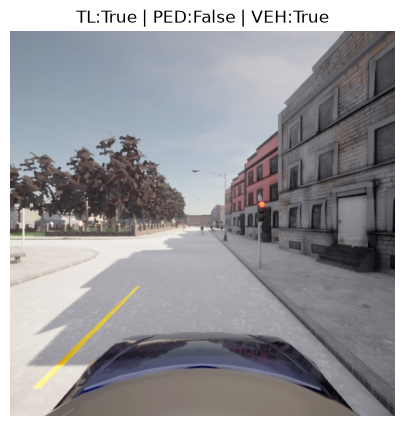

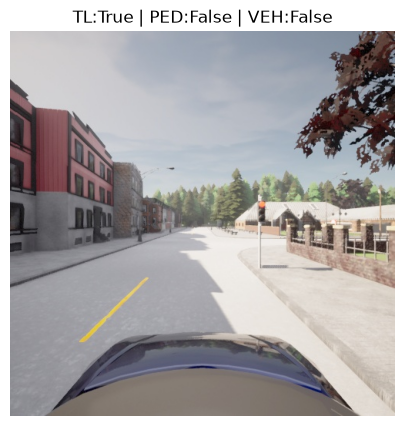

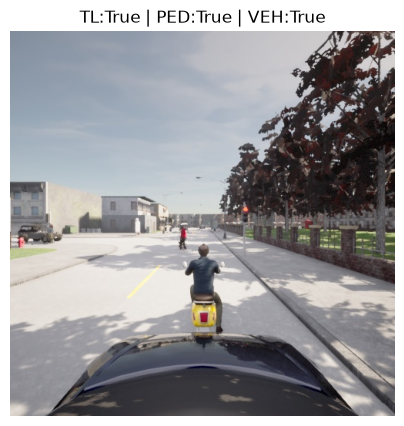

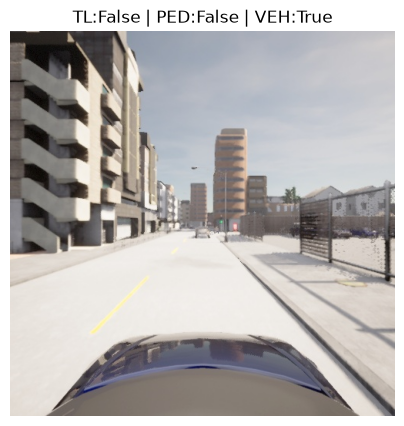

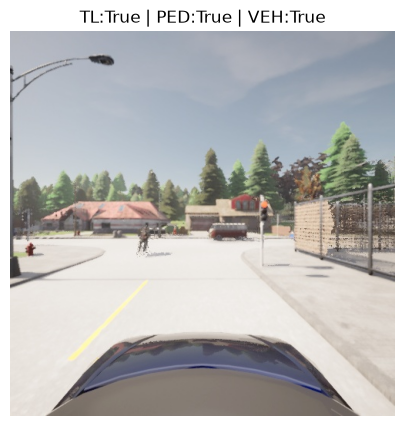

In [30]:
import sys
!{sys.executable} -m pip install pillow
from PIL import Image
import matplotlib.pyplot as plt

for _, row in sample_rows.iterrows():

    frame = str(row['frame']).zfill(6)
    
    img = Image.open(f'train/rgb-front/{frame}.jpg')

    plt.figure(figsize=(5,5))
    plt.imshow(img)

    title = f"TL:{row['has_traffic_light']} | PED:{row['has_pedestrian']} | VEH:{row['has_vehicle']}"
    
    plt.title(title)

    plt.axis('off')
    plt.show()

# Exercise 3.5: Train Three Binary Classifiers


In [31]:
import torch
import torchvision

print(torch.__version__)

2.12.1+cpu


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt

In [33]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):

        self.labels = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])


        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(label)

define image transformations.
Neural networks cannot directly use raw images.
We must:

resize them
convert to tensors
normalize them

Why 224×224?
Because ResNet18 expects that size.

In [34]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# train the vehicle classifier

create datasets

In [35]:
train_dataset = CarlaDataset(

    csv_file='train/labels.csv',

    img_dir='train/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='validation/labels.csv',

    img_dir='validation/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

create dataloaders

This prepares batches for training.

In [36]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

load ResNet18 and load already trained on ImageNet

In [37]:
model = models.resnet18(pretrained=True)

Now replace final layer:
because, Original ResNet predicts 1000 classes.

In [38]:
model.fc = nn.Linear(model.fc.in_features, 1)

Binary Cross Entropy loss
Adam optimizer
learning rate = 0.001

In [39]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

for mac m1 pro, we can use Apple Silicon acceleration.

In [40]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(device)

cpu


Now move model to device:

In [41]:
model = model.to(device)

In [52]:
print(type(val_dataset))
print(val_dataset.__dict__)

<class '__main__.CarlaDataset'>
{'labels':       frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0         0              False            True        False                 0   
1        10               True           False        False               347   
2        20               True           False        False               347   
3        30               True           False        False               347   
4        40               True           False        False               347   
...     ...                ...             ...          ...               ...   
3595  35950               True            True         True                68   
3596  35960               True            True         True               250   
3597  35970               True            True         True                60   
3598  35980               True           False         True                93   
3599  35990               True           False         True       

In [57]:
validation_labels = pd.read_csv("validation/labels.csv")
print(len(validation_labels))
print(len(os.listdir("validation/rgb-front")))

3600
3600


## actual training

In [ ]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

In [43]:
import os

print(os.path.exists("validation/rgb-front/012000.jpg"))

False


Now we plot plot the losses.

In [ ]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Vehicle Classifier Loss')

plt.legend()

plt.show()

# 2. train the Pedestrian classifier

In [54]:
train_dataset = CarlaDataset(

    csv_file='train/labels.csv',

    img_dir='train/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='validation/labels.csv',

    img_dir='validation/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

In [55]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

### reinitialize model again:

In [56]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

C:\Users\HP\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HP\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

In [32]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.5128
Validation Loss: 0.5690
Epoch 2/5
Train Loss: 0.4310
Validation Loss: 0.5949
Epoch 3/5
Train Loss: 0.3676
Validation Loss: 0.5181
Epoch 4/5
Train Loss: 0.3174
Validation Loss: 0.6950
Epoch 5/5
Train Loss: 0.2686
Validation Loss: 0.7138


### plot

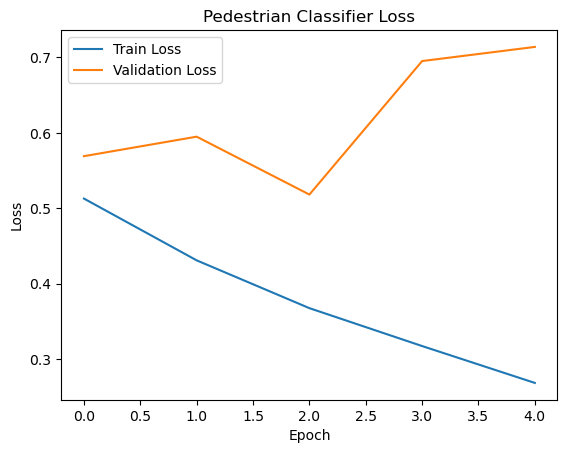

In [34]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Pedestrian Classifier Loss')

plt.legend()

plt.show()

save the ped model

In [35]:
torch.save(model.state_dict(), 'pedestrian_model.pth')

# 3. train the Traffic Light classifier

In [36]:
train_dataset = CarlaDataset(

    csv_file='train/labels.csv',

    img_dir='train/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

val_dataset = CarlaDataset(

    csv_file='validation/labels.csv',

    img_dir='validation/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

In [37]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

### reinitialize model again:

In [38]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)


/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [39]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)

In [40]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)


            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.1975
Validation Loss: 0.1126
Epoch 2/5
Train Loss: 0.0826
Validation Loss: 0.1160
Epoch 3/5
Train Loss: 0.0712
Validation Loss: 0.1121
Epoch 4/5
Train Loss: 0.0527
Validation Loss: 0.0730
Epoch 5/5
Train Loss: 0.0383
Validation Loss: 0.0770


In [41]:
torch.save(model.state_dict(), 'traffic_light_model.pth')

### plot

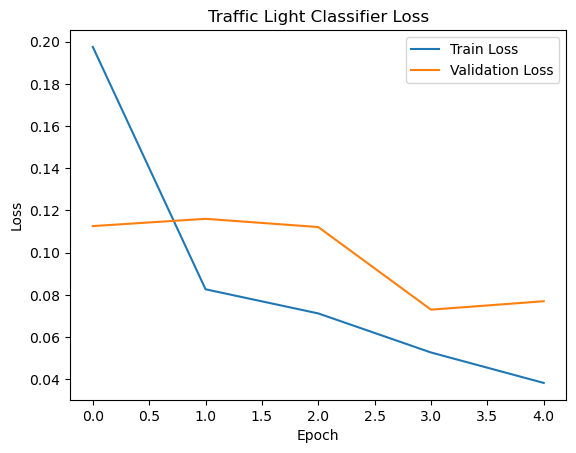

In [43]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Traffic Light Classifier Loss')

plt.legend()

plt.show()

# Exercise 3.6: Evaluation

install sklearn

In [ ]:
pip install scikit-learn

run these after restart

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


load models

In [8]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)

model.load_state_dict(torch.load('pedestrian_model.pth'))

model = model.to(device)

create test dataset [vehicle classifier]

In [ ]:
test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

evaluation code

This collects:
predictions
true labels

In [ ]:

model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

metrics

In [47]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds)

recall = recall_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds)


print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-score:", f1)

Accuracy: 0.7180555555555556
Precision: 0.363395225464191
Recall: 0.5821529745042493
F1-score: 0.44746869896570496


## test dataset: pedestrian classifier

In [ ]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [24]:
test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

Temperature Evaluation & Store Probabilities

In [26]:
temperatures = [0.5, 1.0, 2.0]

results = {}

for T in temperatures:

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs / T)

            if len(all_probs) == 0:

                print(f"\nprobabilities for T = {T}")

                print(probs[:5])

            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy().flatten())
            
            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.numpy())
            

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    results[T] = all_probs

    print(f"\nTemperature = {T}")

    print("Accuracy:", accuracy)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1-score:", f1)


probabilities for T = 0.5
tensor([[3.4293e-07],
        [6.9744e-08],
        [6.4291e-08],
        [7.4042e-08],
        [7.1292e-08]], device='mps:0')

Temperature = 0.5
Accuracy: 0.7180555555555556
Precision: 0.363395225464191
Recall: 0.5821529745042493
F1-score: 0.44746869896570496

probabilities for T = 1.0
tensor([[0.0006],
        [0.0003],
        [0.0003],
        [0.0003],
        [0.0003]], device='mps:0')

Temperature = 1.0
Accuracy: 0.7180555555555556
Precision: 0.363395225464191
Recall: 0.5821529745042493
F1-score: 0.44746869896570496

probabilities for T = 2.0
tensor([[0.0236],
        [0.0160],
        [0.0157],
        [0.0162],
        [0.0161]], device='mps:0')

Temperature = 2.0
Accuracy: 0.7180555555555556
Precision: 0.363395225464191
Recall: 0.5821529745042493
F1-score: 0.44746869896570496


Plot Distributions

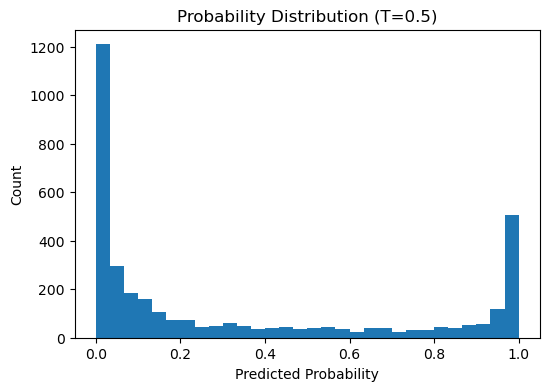

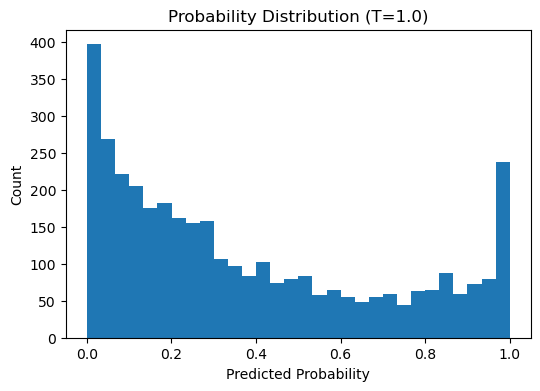

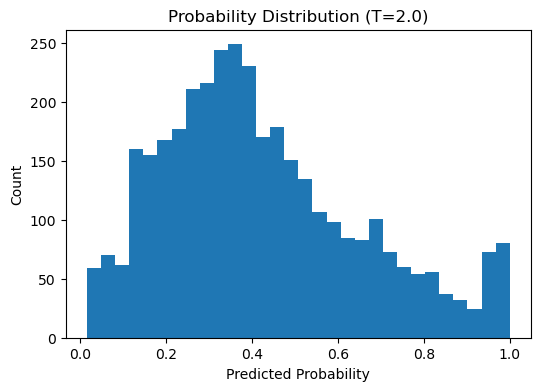

In [27]:
import matplotlib.pyplot as plt

for T in temperatures:

    plt.figure(figsize=(6,4))

    plt.hist(results[T], bins=30)

    plt.title(f"Probability Distribution (T={T})")

    plt.xlabel("Predicted Probability")

    plt.ylabel("Count")

    plt.show()